{'bacteria': 2, 'blight': 0, 'disease': 16, 'fung': 2, 'host': 8, 'infect': 6, 'leaf': 1, 'pathogen': 17, 'resist': 4, 'sympthom': 0, 'wilt': 0}
Note: The following words were not found: blight, sympthom, wilt
0.9999952129289216

Source URL: https://en.wikipedia.org/?curid=147484


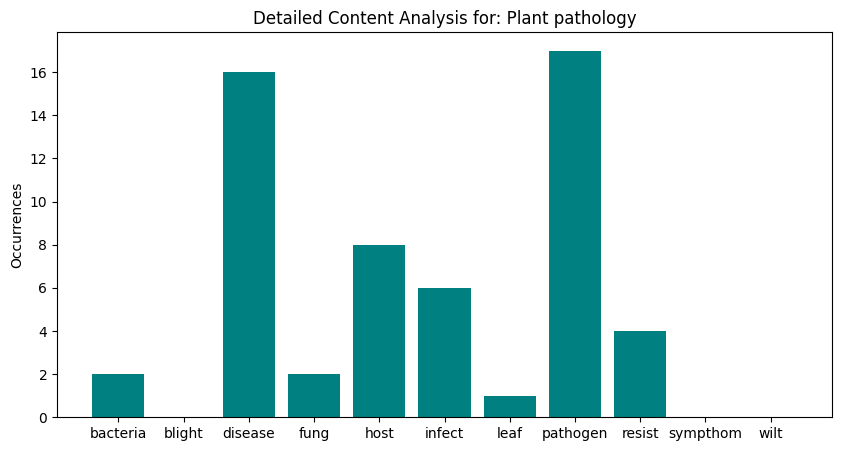

In [17]:
import requests
import re
import matplotlib.pyplot as plt
import firebase_admin
from firebase_admin import credentials, db

# --- Part 1: Search Engine Class ---
class WikiSearchEngine:
    def __init__(self):
        self.base_url = "https://en.wikipedia.org/w/api.php"

    def fetch_wiki_content(self, topic):
        params = {
            "action": "query",
            "format": "json",
            "titles": topic,
            "prop": "extracts",
            "explaintext": True,
        }
        headers = {"User-Agent": "PlantProject/1.0"}
        try:
            response = requests.get(self.base_url, params=params, headers=headers)
            pages = response.json()['query']['pages']
            page = next(iter(pages.values()))
            content = page.get('extract', '')
            url = f"https://en.wikipedia.org/?curid={page.get('pageid')}"
            return content, url
        except: return '', ''

    def build_index(self, content, target_words, url):
        text_lower = content.lower()
        index = {}

        for word in target_words:
            # סופר את כל המופעים (כולל 0)
            count = len(re.findall(word.lower(), text_lower))
            # אנחנו מכניסים למילון את המילה גם אם ה-count הוא 0
            index[word] = {"count": count, "url": url}
        return index

# --- Part 2: Firebase Functions ---
def sync_data(data):
    if not firebase_admin._apps:
        cred = credentials.Certificate('serviceAccountKey.json')
        firebase_admin.initialize_app(cred, {'databaseURL': 'https://proj2-d34ed-default-rtdb.firebaseio.com'})
    db.reference('plant_index').set(data)

def get_data():
    return db.reference('plant_index').get()

# --- Part 3: Main Execution ---
def main():
    query_roots = [
        "fung", "bacteria", "infect", "pathogen", "leaf",
        "resist", "sympthom", "blight", "wilt", "host","disease"
    ]

    search_topic = "Plant pathology"
    engine = WikiSearchEngine()
    content, url = engine.fetch_wiki_content(search_topic)

    if content:
        local_index = engine.build_index(content, query_roots, url)

        sync_data(local_index)
        results_from_db = get_data()

        display_dict = {word: info['count'] for word, info in results_from_db.items()}
        print(display_dict)

        missing_words = [word for word, count in display_dict.items() if count == 0]
        if missing_words:
            print(f"Note: The following words were not found: {', '.join(missing_words)}")

        rank = 1
        for info in results_from_db.values():
            count = info['count']
            if count > 0:
                rank = rank * (1/count)

        rank = 1 - rank
        print(rank)

        print(f"\nSource URL: {url}")

        plt.figure(figsize=(10, 5))
        plt.bar(display_dict.keys(), display_dict.values(), color='teal')
        plt.title(f"Detailed Content Analysis for: {search_topic}")
        plt.ylabel("Occurrences")
        plt.show()

if __name__ == "__main__":
    main()